In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
train_df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')

In [3]:
train_df.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [4]:
train_df = train_df.drop(['Name', 'Ticket', 'Cabin'], axis=1)

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

class EDAVisualizer:
    def __init__(self, df, target=None):
        self.df = df
        self.target = target
        self.num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
        self.cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
        
        if target in self.num_cols:
            self.num_cols.remove(target)
        if target in self.cat_cols:
            self.cat_cols.remove(target)

    def univariate(self):
        print("=== Univariate Analysis ===")

        # Numerical
        for col in self.num_cols:
            plt.figure(figsize=(6,3))
            sns.histplot(self.df[col], kde=True)
            plt.title(f'Distribution of {col}')
            plt.show()

        # Categorical
        for col in self.cat_cols:
            plt.figure(figsize=(6,3))
            sns.countplot(x=self.df[col])
            plt.title(f'Count of {col}')
            plt.xticks(rotation=45)
            plt.show()

    def bivariate(self):
        if not self.target:
            print("No target defined!")
            return

        print("=== Bivariate Analysis ===")

        # Numerical vs Target
        for col in self.num_cols:
            plt.figure(figsize=(6,3))
            sns.boxplot(x=self.df[self.target], y=self.df[col])
            plt.title(f'{col} vs {self.target}')
            plt.show()

        # Categorical vs Target
        for col in self.cat_cols:
            plt.figure(figsize=(6,3))
            sns.countplot(x=self.df[col], hue=self.df[self.target])
            plt.title(f'{col} vs {self.target}')
            plt.xticks(rotation=45)
            plt.show()

    def multivariate(self):
        print("=== Multivariate Analysis ===")

        # Correlation Heatmap
        plt.figure(figsize=(10,6))
        sns.heatmap(self.df[self.num_cols + [self.target]].corr(), annot=True, cmap='coolwarm')
        plt.title("Correlation Heatmap")
        plt.show()

        # Pairplot
        sns.pairplot(self.df[self.num_cols + [self.target]], hue=self.target)
        plt.show()

# Univariate

=== Univariate Analysis ===


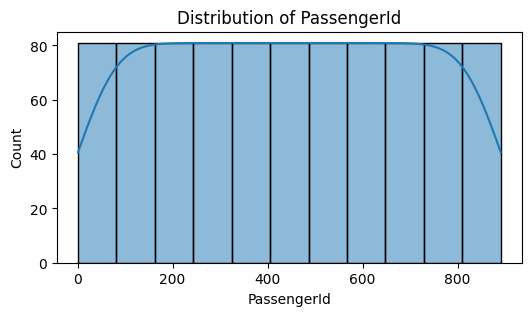

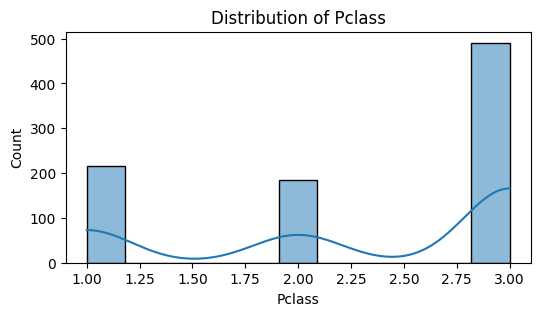

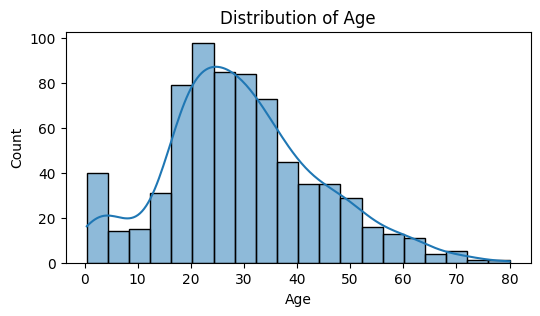

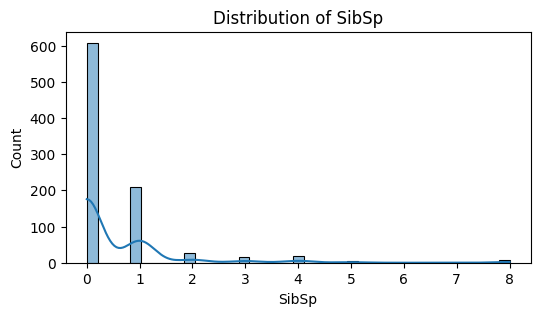

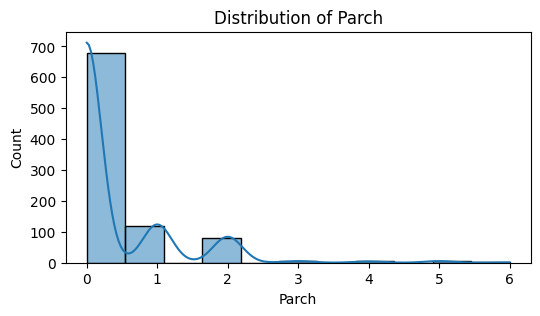

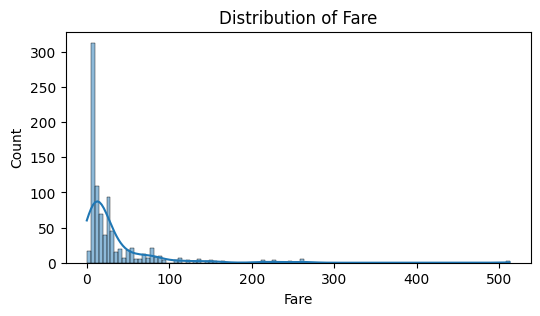

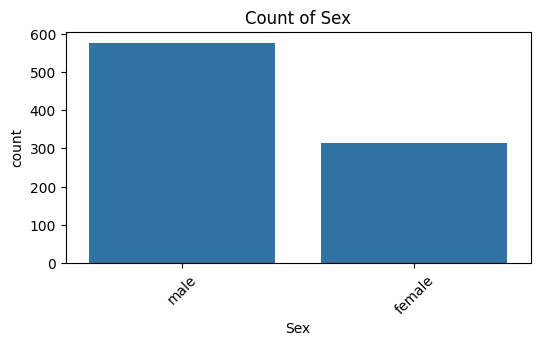

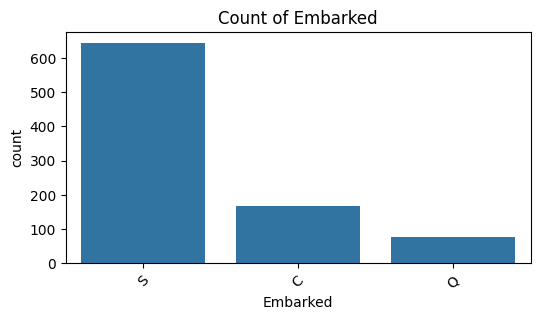

In [6]:
eda = EDAVisualizer(train_df, target="Survived")

eda.univariate()

# Bivariate

=== Bivariate Analysis ===


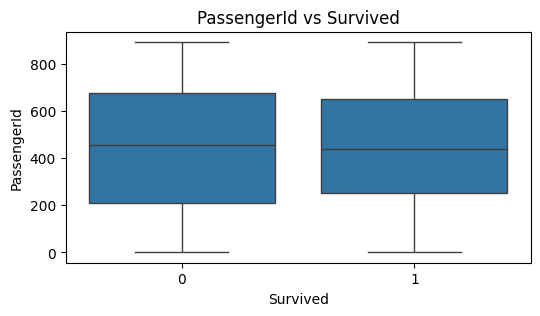

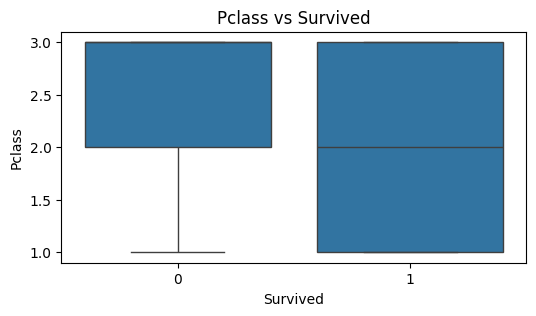

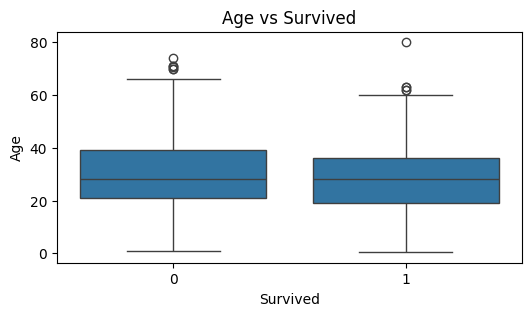

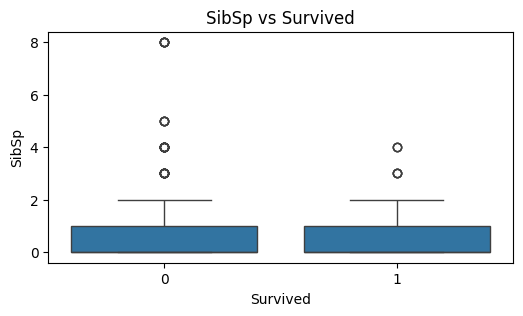

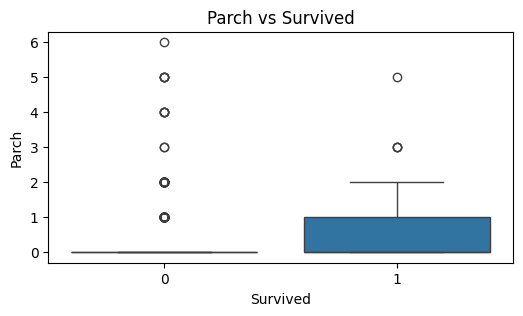

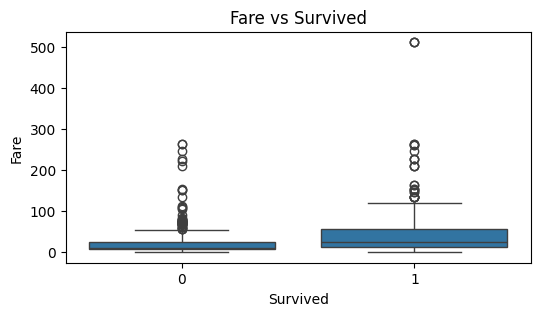

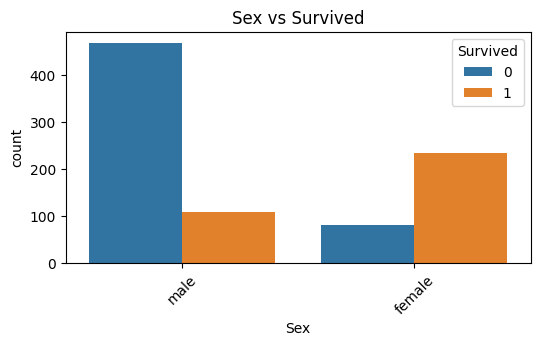

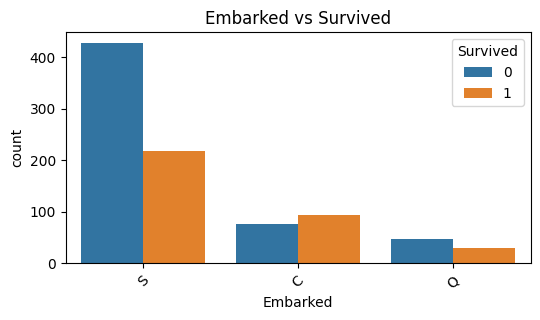

In [7]:
eda.bivariate()

# Multivariate

=== Multivariate Analysis ===


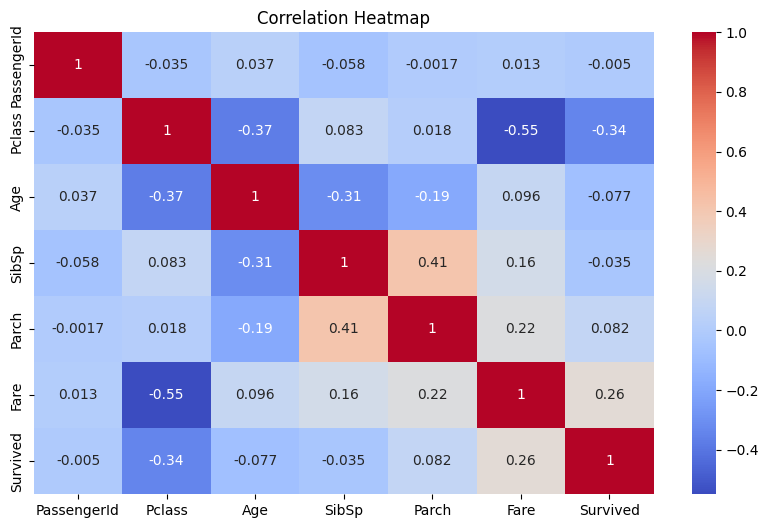

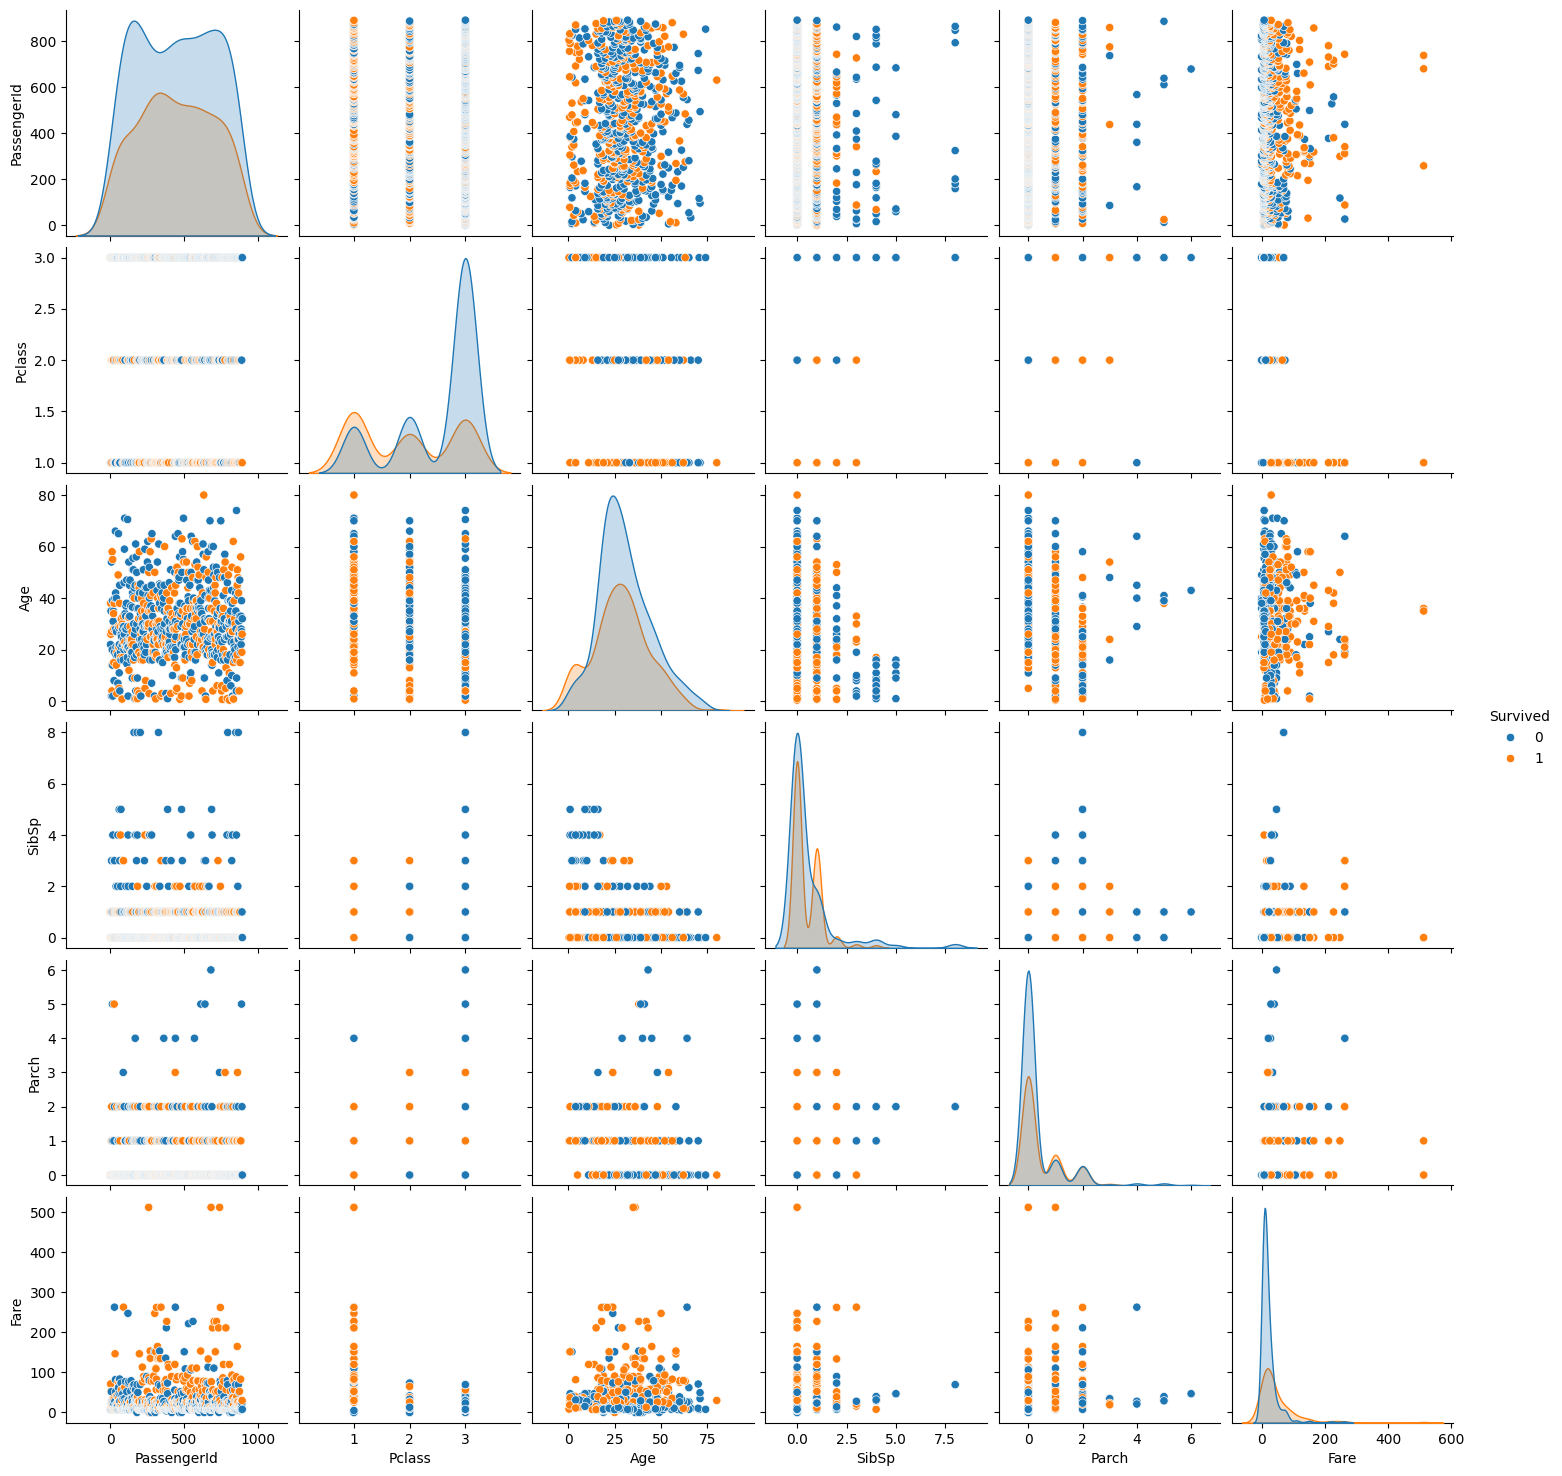

In [8]:
eda.multivariate()